In [1]:
#Supp figs model oder
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import glob, os
import matplotlib.pyplot as plt

def read_sumstats_REGENIE(fn, drop_cols = None):
    """
    Reads sumstats
    
    Converts regenie output to MRP format (PLINK-like)
    - add necessary column
    - change column names
    
    """
    #load data
    data = pd.read_csv(fn, sep="\t")

    # remove lines without chromosome number
    data.loc[data["CHROM"] == "X" , "CHROM"] = 23
    data.loc[data["CHROM"] == "XY" , "CHROM"] = 23

    for col in data.columns:
        data = data[data[col] != col]

    # convert dtype
    for col in ["CHROM", "GENPOS", "N"]:
        data[col] = data[col].round(0).astype("int64")
    for col in ["A1FREQ", "INFO",  "BETA", "SE", "CHISQ", "LOG10P"]:
        data[col] = data[col].astype("float64")

    #get non-logP for FUMA
    data["P"] = np.power(10, -data["LOG10P"])
    
    if drop_cols:
        data.drop(drop_cols, axis=1, inplace=True)
    
    #use unique ID
    return data.set_index("ID")

def get_cumulative_pos(df):
    running_pos = float(0)

    cumulative_pos = []

    for chrom, group_df in df.groupby('CHROM'):
        chr_df = np.add(group_df['GENPOS'].astype("int64"), running_pos)
        cumulative_pos.append(chr_df)
        running_pos += float(group_df['GENPOS'].max())

    df['cumulative_pos'] = pd.concat(cumulative_pos)
    
    return df

def manhattan(df, ax, alpha, in_palette, x, y, hue):
    
    g = sns.scatterplot(
        data = df,
        x = x,
        y = y,
        hue = hue,
        palette = in_palette,
        linewidth=0,
        s=6,
        zorder=2,
        ax=ax,
        legend=None,
        style=None
    )
    
    ax.plot([np.min(df["cumulative_pos"]), np.max(df["cumulative_pos"])], [alpha, alpha], "--", color="black")

    ax.set_xticks(df.groupby(hue)['cumulative_pos'].median())
    ax.tick_params(which='major', width=0.3, length=2, labelsize=8)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_visible(True)

In [2]:
in_path = r"P:\workspaces\lg-ukbiobank\projects\CONGRADS_rest"

nms = []

for g in ["g1"]:
    for roi in ["lifg", "lstg"]:
        for i in range(3):
            nms.append("CONGRADS_gwas_cmaps_65k_melodic_{0}_cmap_{1}_oic_{2}.regenie".format(g, roi, i))    

gwass = []

for nm in nms:
    fn = os.path.join(in_path, nm)
    print(fn)
    #load data
    data = read_sumstats_REGENIE(fn)
    data = data[data["P"] < 0.9]
    #data = get_cumulative_pos(data)
    gwass.append(data)

P:\workspaces\lg-ukbiobank\projects\CONGRADS_rest\CONGRADS_gwas_cmaps_65k_melodic_g1_cmap_lifg_oic_0.regenie
P:\workspaces\lg-ukbiobank\projects\CONGRADS_rest\CONGRADS_gwas_cmaps_65k_melodic_g1_cmap_lifg_oic_1.regenie
P:\workspaces\lg-ukbiobank\projects\CONGRADS_rest\CONGRADS_gwas_cmaps_65k_melodic_g1_cmap_lifg_oic_2.regenie
P:\workspaces\lg-ukbiobank\projects\CONGRADS_rest\CONGRADS_gwas_cmaps_65k_melodic_g1_cmap_lstg_oic_0.regenie
P:\workspaces\lg-ukbiobank\projects\CONGRADS_rest\CONGRADS_gwas_cmaps_65k_melodic_g1_cmap_lstg_oic_1.regenie
P:\workspaces\lg-ukbiobank\projects\CONGRADS_rest\CONGRADS_gwas_cmaps_65k_melodic_g1_cmap_lstg_oic_2.regenie


C:\Users\jitame\AppData\Local\Temp\ipykernel_19480\388401611.py:63: UserWarning: 
The palette list has fewer values (2) than needed (23) and will cycle, which may produce an uninterpretable plot.
  g = sns.scatterplot(
C:\Users\jitame\AppData\Local\Temp\ipykernel_19480\388401611.py:63: UserWarning: 
The palette list has fewer values (2) than needed (23) and will cycle, which may produce an uninterpretable plot.
  g = sns.scatterplot(
C:\Users\jitame\AppData\Local\Temp\ipykernel_19480\388401611.py:63: UserWarning: 
The palette list has fewer values (2) than needed (23) and will cycle, which may produce an uninterpretable plot.
  g = sns.scatterplot(
C:\Users\jitame\AppData\Local\Temp\ipykernel_19480\388401611.py:63: UserWarning: 
The palette list has fewer values (2) than needed (23) and will cycle, which may produce an uninterpretable plot.
  g = sns.scatterplot(
C:\Users\jitame\AppData\Local\Temp\ipykernel_19480\388401611.py:63: UserWarning: 
The palette list has fewer values (2) than

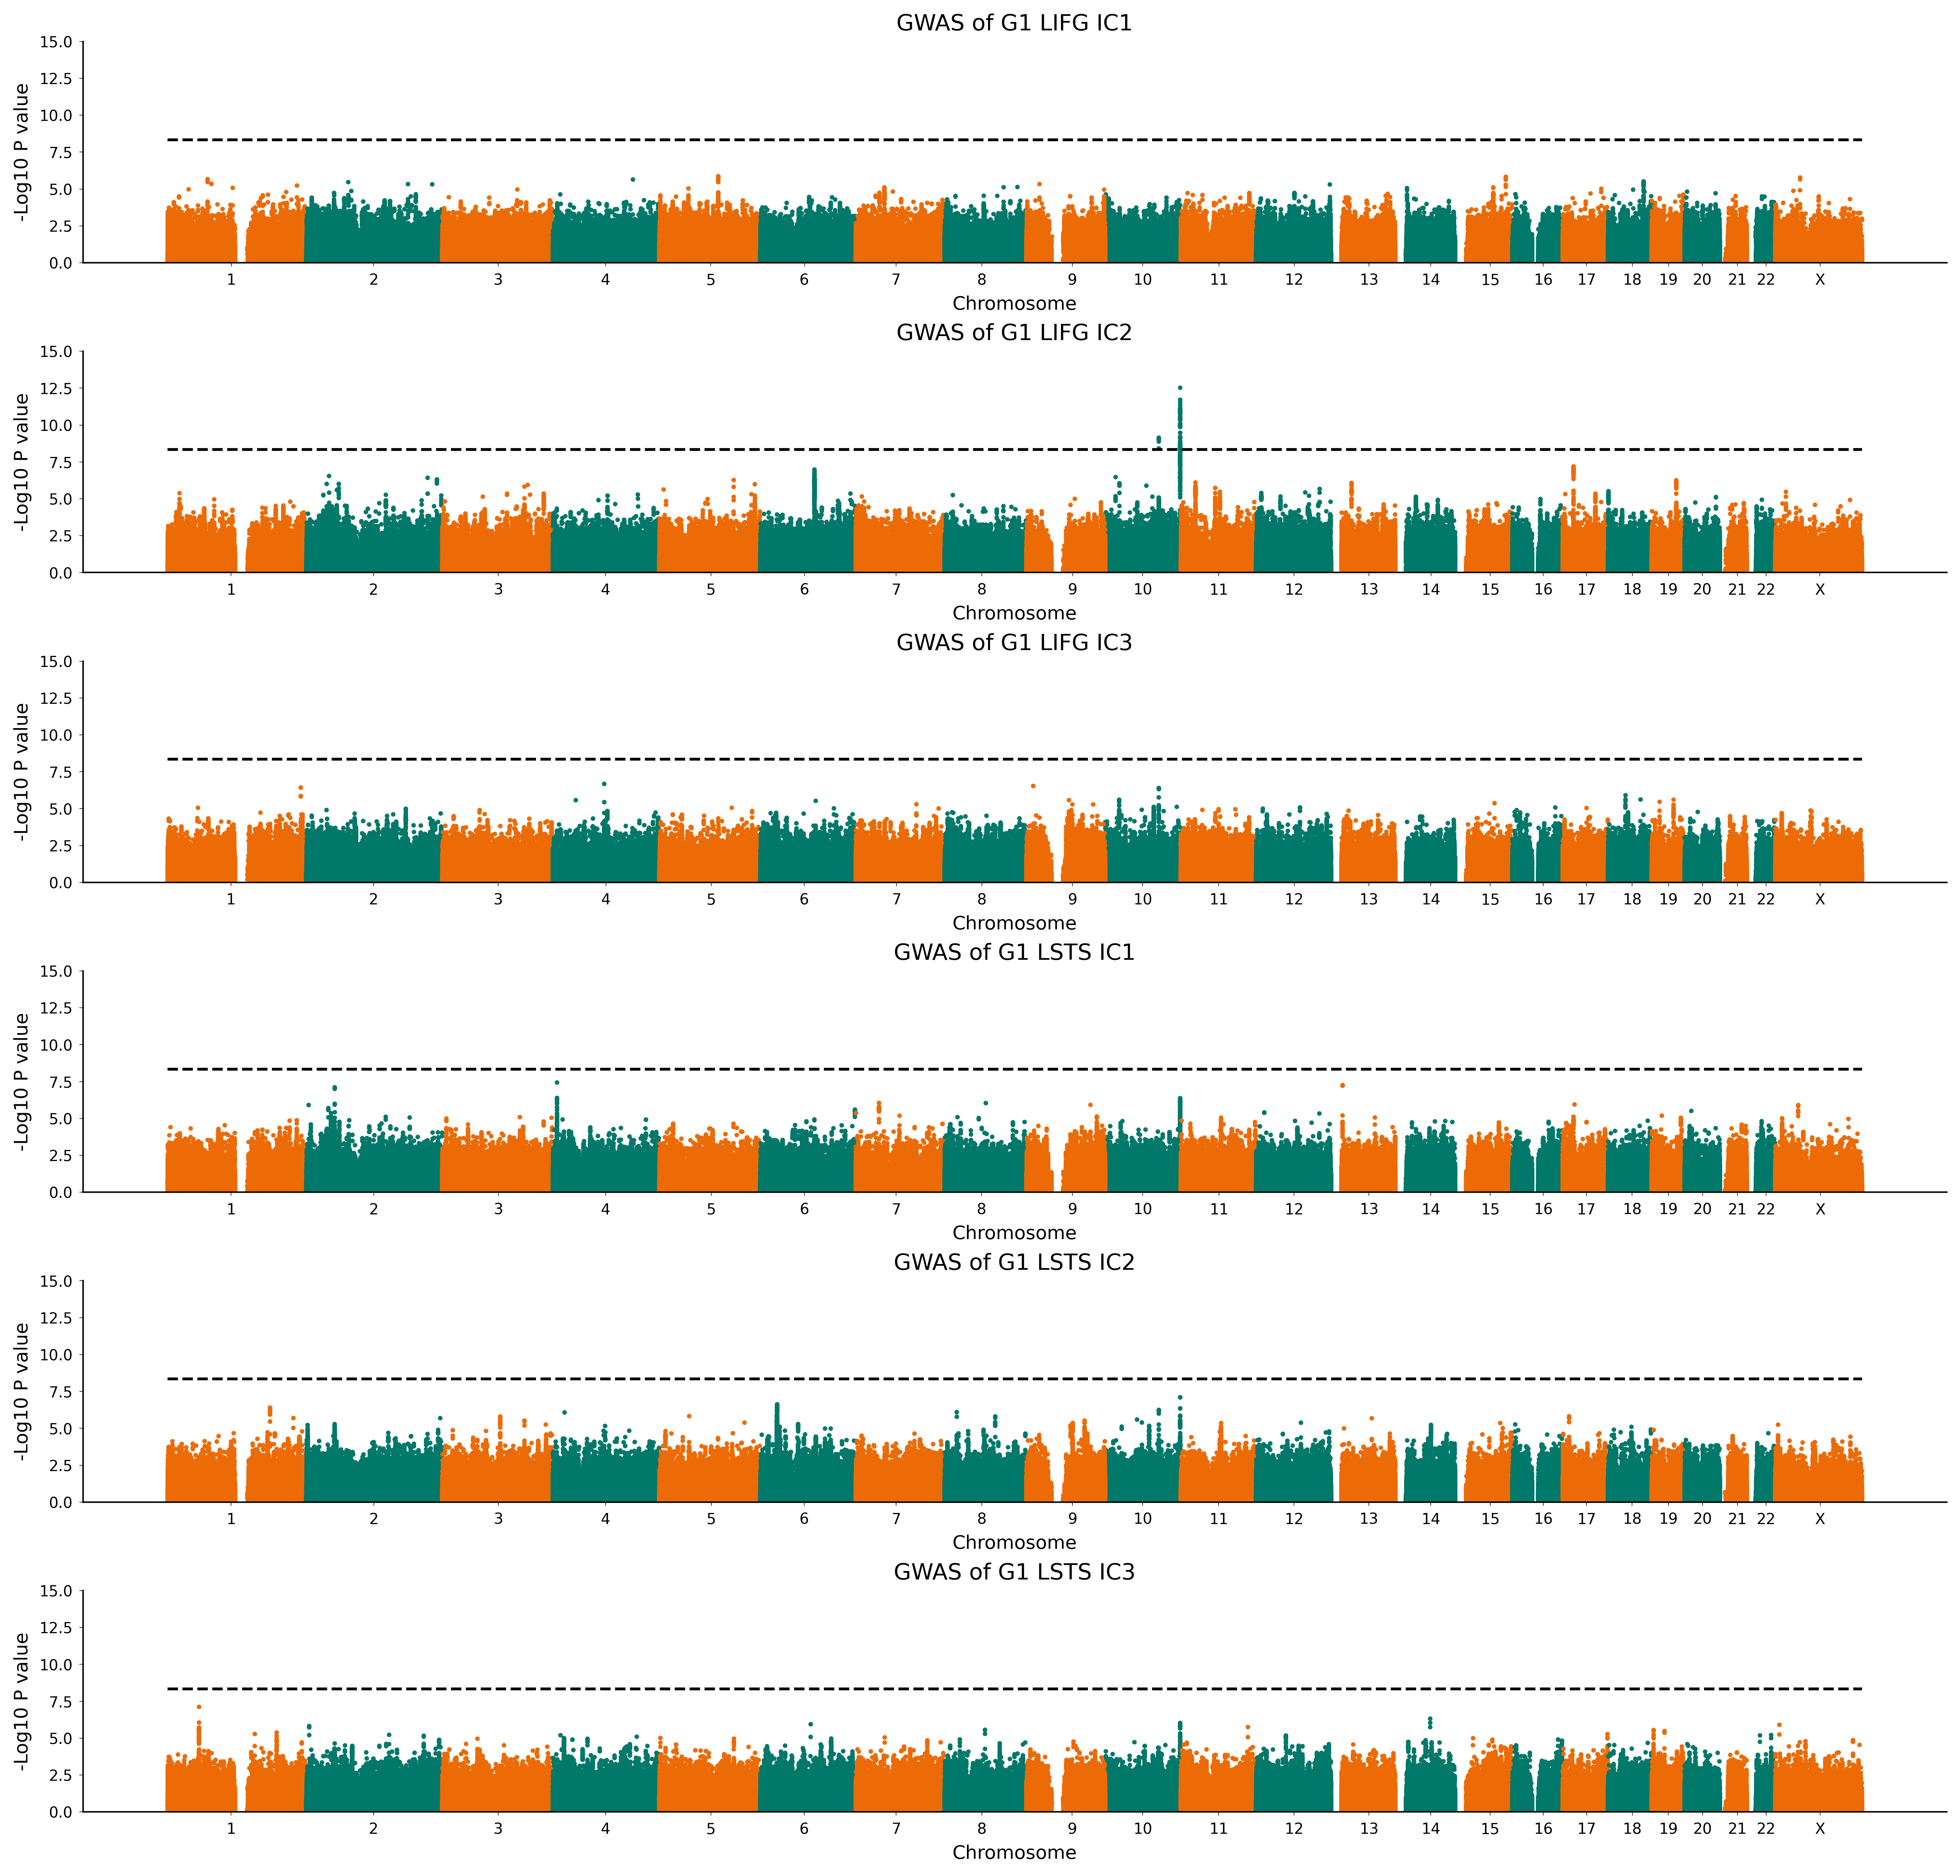

In [3]:
import matplotlib.gridspec as gridspec
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib import colors as mcolors, path
import seaborn as sns

colors = [ '#ED6B06', '#00786A']
#palette = LinearSegmentedColormap.from_list("custom_palette", colors)
#palette = ListedColormap(colors)
palette = sns.color_palette(colors)


fig = plt.figure(figsize=(17.8, 20), dpi=400)
gs = gridspec.GridSpec(7, 1, height_ratios=[1]*7, hspace=0.4)

xticklabels = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, "X"]

sig_manhattan = -np.log10(0.05/11000000)

titles = [ "G1 LIFG IC1", "G1 LIFG IC2", "G1 LIFG IC3", "G1 LSTS IC1", "G1 LSTS IC2", "G1 LSTS IC3"]

x_manhattan = 'cumulative_pos'
y_manhattan = 'LOG10P'
hue_manhattan = 'CHROM'


for i in range(6):
    df = gwass[i]
    ax1 = fig.add_subplot(gs[i])
    manhattan(df, ax1, alpha=sig_manhattan, in_palette=palette, x=x_manhattan, y=y_manhattan, hue=hue_manhattan)
    ax1.set_title("GWAS of {}".format(titles[i]))
    ax1.set_ylim(0, 15)
    ax1.set_xlabel('Chromosome', fontsize=10)
    ax1.set_ylabel('-Log10 P value', fontsize=10)
    ax1.set_xticklabels(xticklabels)
    ax1.tick_params(which='major', width=0.3, length=2, labelsize=8)

plt.savefig(os.path.join(in_path, "results", "CONGRADS_50k_manhattans_cmap_g1.png"), dpi=400, bbox_inches='tight')

P:\workspaces\lg-ukbiobank\projects\CONGRADS_rest\CONGRADS_gwas_cmaps_65k_melodic_g2_cmap_lifg_oic_0.regenie
P:\workspaces\lg-ukbiobank\projects\CONGRADS_rest\CONGRADS_gwas_cmaps_65k_melodic_g2_cmap_lifg_oic_1.regenie
P:\workspaces\lg-ukbiobank\projects\CONGRADS_rest\CONGRADS_gwas_cmaps_65k_melodic_g2_cmap_lstg_oic_0.regenie
P:\workspaces\lg-ukbiobank\projects\CONGRADS_rest\CONGRADS_gwas_cmaps_65k_melodic_g2_cmap_lstg_oic_1.regenie
P:\workspaces\lg-ukbiobank\projects\CONGRADS_rest\CONGRADS_gwas_cmaps_65k_melodic_g2_cmap_lstg_oic_2.regenie


C:\Users\jitame\AppData\Local\Temp\ipykernel_19480\388401611.py:63: UserWarning: 
The palette list has fewer values (2) than needed (23) and will cycle, which may produce an uninterpretable plot.
  g = sns.scatterplot(
C:\Users\jitame\AppData\Local\Temp\ipykernel_19480\388401611.py:63: UserWarning: 
The palette list has fewer values (2) than needed (23) and will cycle, which may produce an uninterpretable plot.
  g = sns.scatterplot(
C:\Users\jitame\AppData\Local\Temp\ipykernel_19480\388401611.py:63: UserWarning: 
The palette list has fewer values (2) than needed (23) and will cycle, which may produce an uninterpretable plot.
  g = sns.scatterplot(
C:\Users\jitame\AppData\Local\Temp\ipykernel_19480\388401611.py:63: UserWarning: 
The palette list has fewer values (2) than needed (23) and will cycle, which may produce an uninterpretable plot.
  g = sns.scatterplot(
C:\Users\jitame\AppData\Local\Temp\ipykernel_19480\388401611.py:63: UserWarning: 
The palette list has fewer values (2) than

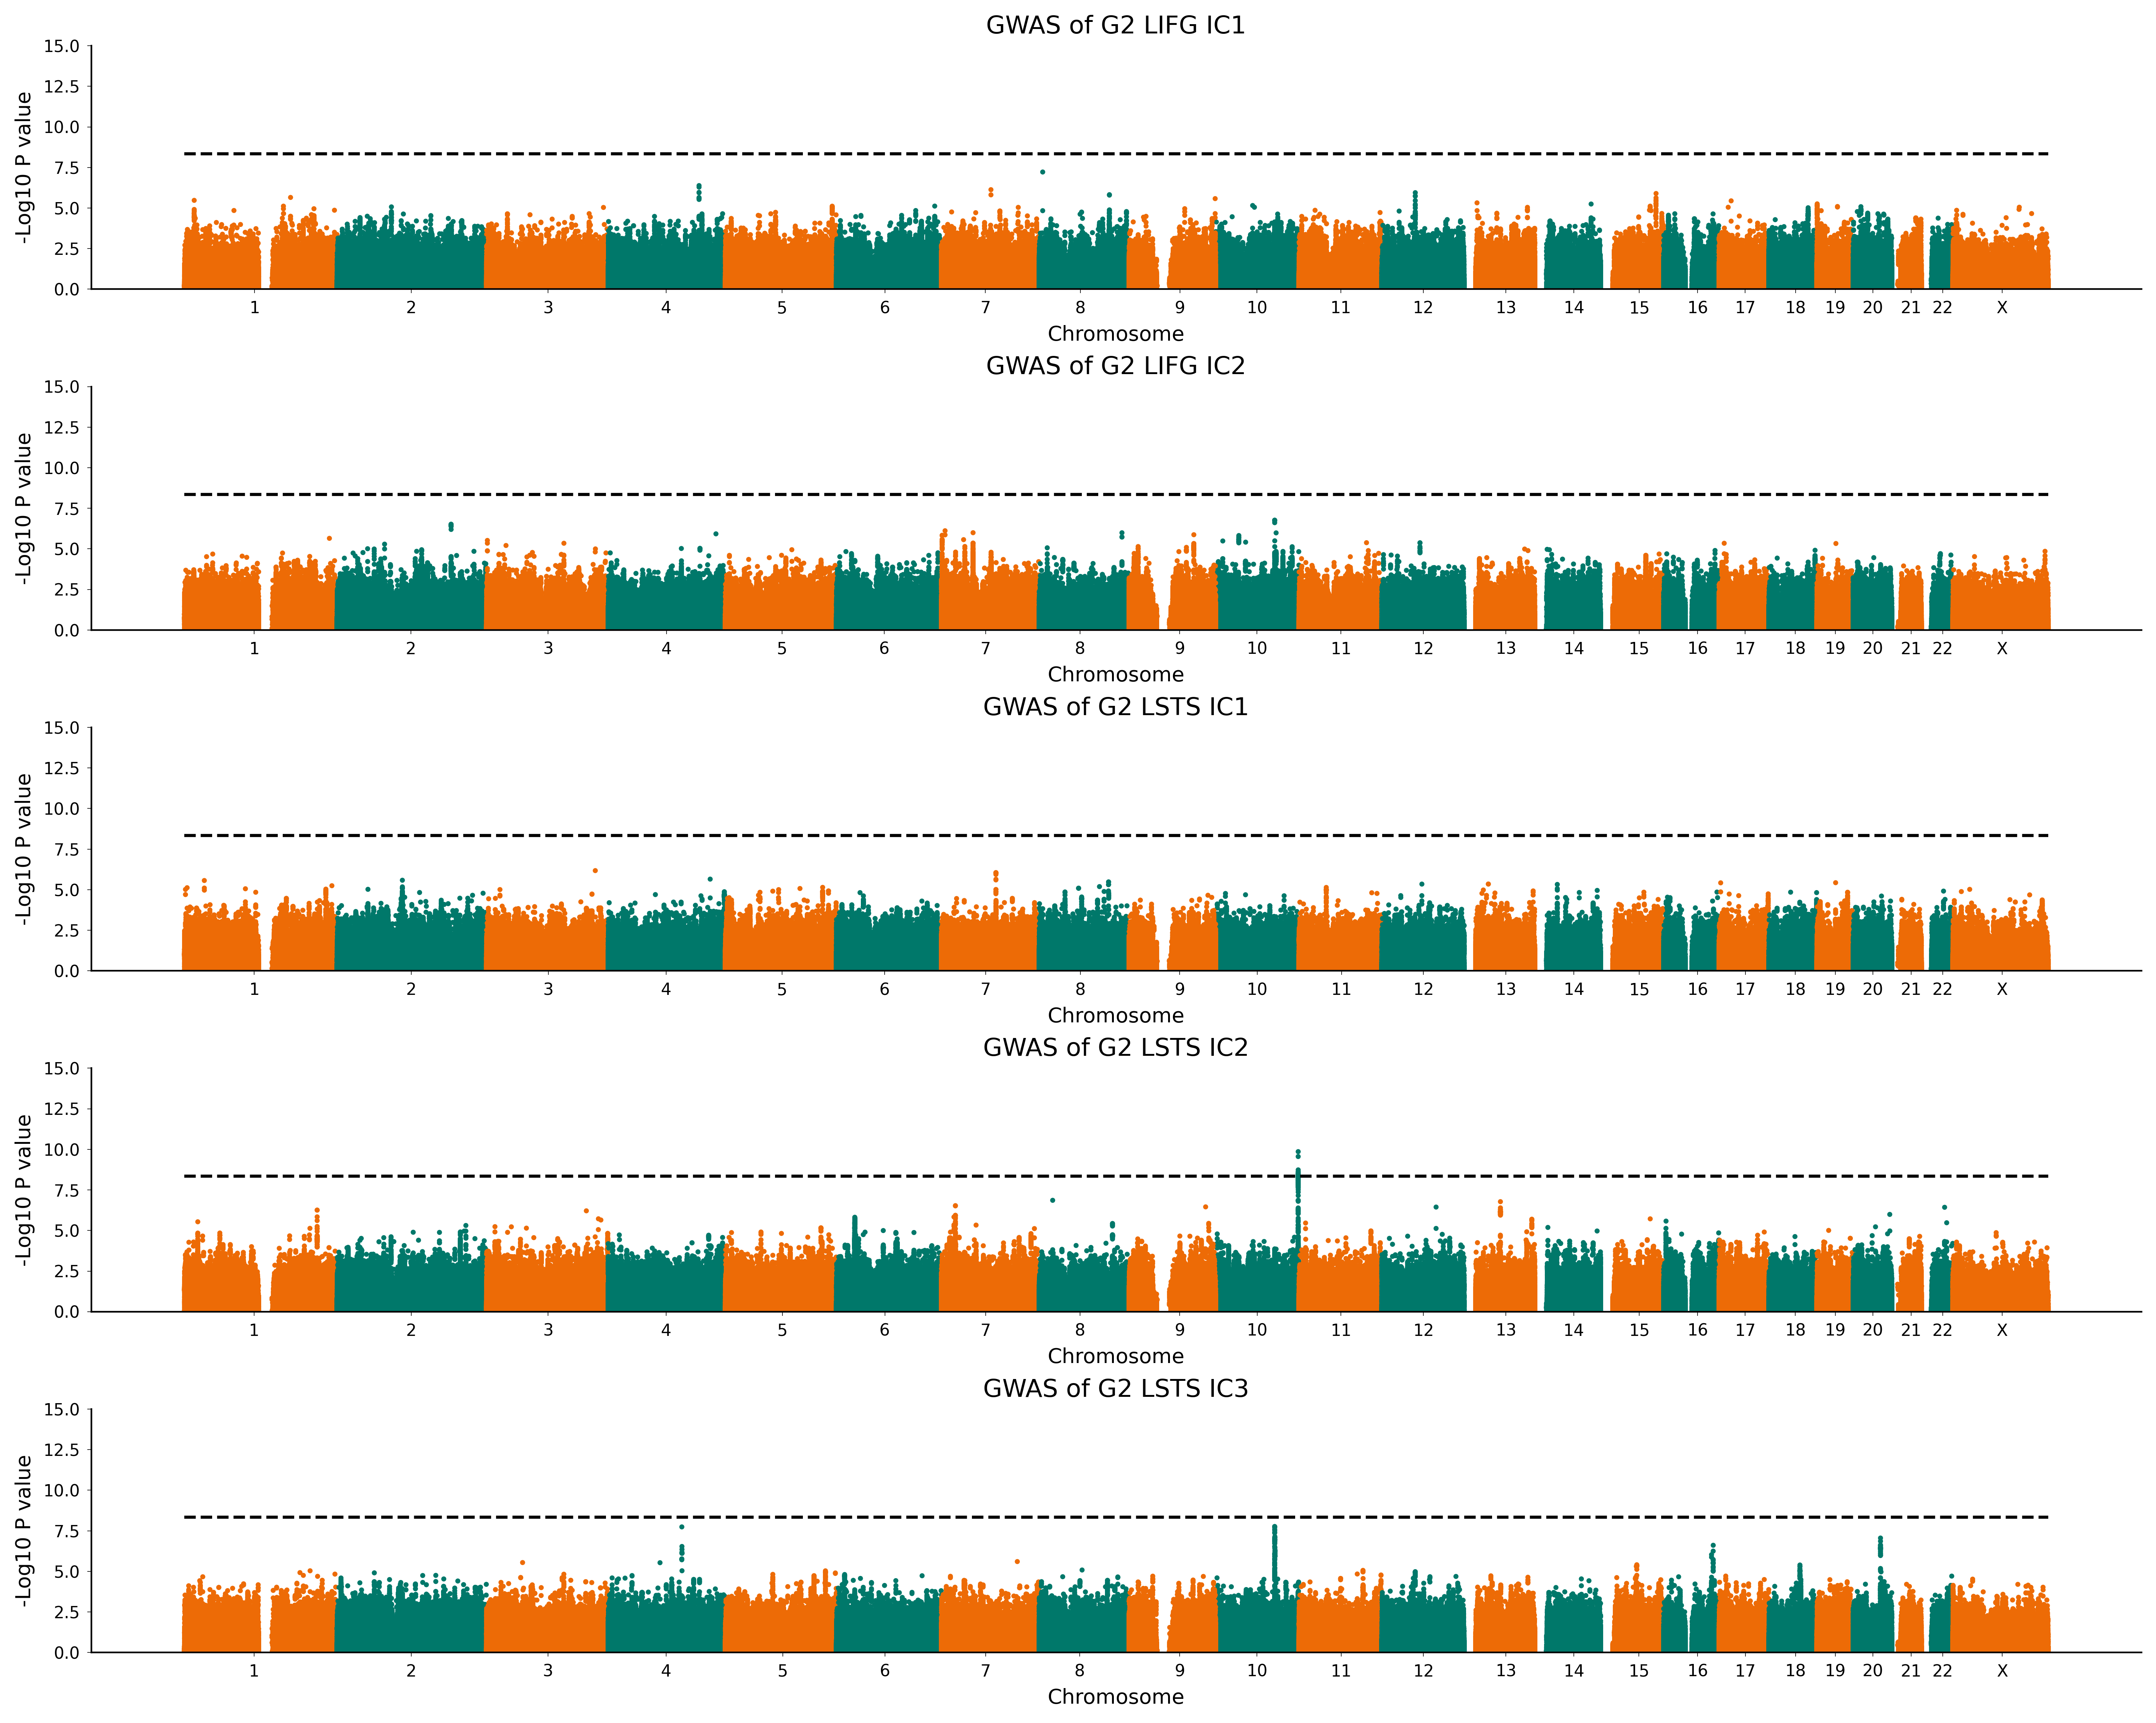

In [4]:
del gwass

import matplotlib.gridspec as gridspec
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib import colors as mcolors, path
import seaborn as sns

in_path = r"P:\workspaces\lg-ukbiobank\projects\CONGRADS_rest"

nms = []

for g in ["g2"]:
    for roi in ["lifg", "lstg"]:
        for i in range(3):
            if not (g == "g2" and roi == "lifg" and i == 2):
                nms.append("CONGRADS_gwas_cmaps_65k_melodic_{0}_cmap_{1}_oic_{2}.regenie".format(g, roi, i))
    

gwass = []

for nm in nms:
        fn = os.path.join(in_path, nm)
        print(fn)
        #load data
        data = read_sumstats_REGENIE(fn)
        data = data[data["P"] < 0.9]
        #data = get_cumulative_pos(data)
        gwass.append(data)



colors = [ '#ED6B06', '#00786A']
#palette = LinearSegmentedColormap.from_list("custom_palette", colors)
#palette = ListedColormap(colors)
palette = sns.color_palette(colors)


fig = plt.figure(figsize=(17.8, 20), dpi=400)
gs = gridspec.GridSpec(7, 1, height_ratios=[1]*7, hspace=0.4)

xticklabels = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, "X"]

sig_manhattan = -np.log10(0.05/11000000)

titles = [ "G2 LIFG IC1", "G2 LIFG IC2", "G2 LSTS IC1", "G2 LSTS IC2", "G2 LSTS IC3"]

x_manhattan = 'cumulative_pos'
y_manhattan = 'LOG10P'
hue_manhattan = 'CHROM'


for i in range(5):
    df = gwass[i]
    ax1 = fig.add_subplot(gs[i])
    manhattan(df, ax1, alpha=sig_manhattan, in_palette=palette, x=x_manhattan, y=y_manhattan, hue=hue_manhattan)
    ax1.set_title("GWAS of {}".format(titles[i]))
    ax1.set_ylim(0, 15)
    ax1.set_xlabel('Chromosome', fontsize=10)
    ax1.set_ylabel('-Log10 P value', fontsize=10)
    ax1.set_xticklabels(xticklabels)
    ax1.tick_params(which='major', width=0.3, length=2, labelsize=8)

plt.savefig(os.path.join(in_path, "results", "CONGRADS_50k_manhattans_cmap_g2.png"), dpi=400, bbox_inches='tight')

In [5]:
for data in gwass:
    print(data[data["LOG10P"] > sig_manhattan].sort_values(by=["LOG10P"], ascending=False).head(n=20))

#data.sort_values(by=["LOG10P"], ascending=False).head(n=20)

Empty DataFrame
Columns: [CHROM, GENPOS, ALLELE0, ALLELE1, A1FREQ, INFO, N, TEST, BETA, SE, CHISQ, LOG10P, EXTRA, P, cumulative_pos]
Index: []
Empty DataFrame
Columns: [CHROM, GENPOS, ALLELE0, ALLELE1, A1FREQ, INFO, N, TEST, BETA, SE, CHISQ, LOG10P, EXTRA, P, cumulative_pos]
Index: []
Empty DataFrame
Columns: [CHROM, GENPOS, ALLELE0, ALLELE1, A1FREQ, INFO, N, TEST, BETA, SE, CHISQ, LOG10P, EXTRA, P, cumulative_pos]
Index: []
            CHROM     GENPOS ALLELE0 ALLELE1    A1FREQ      INFO      N TEST  \
ID                                                                             
rs7917077      10  134305875       T       A  0.523014  0.988164  43533  ADD   
rs4880259      10  134298687       T       C  0.487003  0.960466  43533  ADD   
rs7894289      10  134305663       G       A  0.512859  0.977187  43533  ADD   
rs10870314     10  134310923       T       G  0.451510  0.996554  43533  ADD   
rs10870313     10  134310920       A       G  0.451630  0.996713  43533  ADD   
rs34102287 